### Import Library

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

### Load Data

In [9]:
data = pd.read_csv('features_data/TCD_Normalized_features.csv')

In [10]:
df_tcd = pd.read_csv("features_data/TCD_Normalized_features.csv")
df_tvoc = pd.read_csv("features_data/TVOC_Normalized_features.csv")
df_combined = pd.read_csv("features_data/Combined_normalized_features.csv")

df_tcd_fnorm = pd.read_csv("features_data/TCD_Filtered_Normalized_features.csv")
df_tvoc_fnorm = pd.read_csv("features_data/TVOC_Filtered_Normalized_features.csv")
df_combined_fnorm = pd.read_csv("features_data/Combined_filtered_normalized_features.csv")

### Label Encoding

In [11]:
le = LabelEncoder()
for df in [df_tcd, df_tvoc, df_combined, df_tcd_fnorm, df_tvoc_fnorm, df_combined_fnorm]:
    df["Label_enc"] = le.fit_transform(df["Label"])

### Columns

In [12]:
tcd_cols = ["TCD_AUC","TCD_Mean","TCD_Max","TCD_Skew","TCD_Kurtosis", "TCD_Decay"]
# tcd_cols = ["TCD_AUC","TCD_Mean","TCD_Max","TCD_Skew","TCD_Kurtosis"]
# tvoc_cols = ["TVOC_AUC","TVOC_Mean","TVOC_Max","TVOC_Skew","TVOC_Kurtosis"]
tvoc_cols = ["TVOC_AUC","TVOC_Mean","TVOC_Max","TVOC_Skew","TVOC_Kurtosis", "TVOC_Decay"]
combined_cols = tcd_cols + tvoc_cols

### Random Forest Importance

In [13]:
def get_importance_with_gridsearch(df, feature_cols):
    X = df[feature_cols]
    y = df["Label_enc"]

    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 5, 10],
        'max_features': ['sqrt', 'log2'],
        'random_state': [42]
    }

    rf = RandomForestClassifier()
    grid_search = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1)
    grid_search.fit(X, y)

    best_rf = grid_search.best_estimator_
    print(f"Best params for {feature_cols[0]}: {grid_search.best_params_}")

    return best_rf.feature_importances_

# Norm
tcd_importances = get_importance_with_gridsearch(df_tcd, tcd_cols)
tvoc_importances = get_importance_with_gridsearch(df_tvoc, tvoc_cols)
combined_importances = get_importance_with_gridsearch(df_combined, combined_cols)

# Fnorm
tcd_importances_fnorm = get_importance_with_gridsearch(df_tcd_fnorm, tcd_cols)
tvoc_importances_fnorm = get_importance_with_gridsearch(df_tvoc_fnorm, tvoc_cols)
combined_importances_fnorm = get_importance_with_gridsearch(df_combined_fnorm, combined_cols)

Best params for TCD_AUC: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200, 'random_state': 42}
Best params for TVOC_AUC: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100, 'random_state': 42}
Best params for TCD_AUC: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100, 'random_state': 42}
Best params for TCD_AUC: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100, 'random_state': 42}
Best params for TVOC_AUC: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100, 'random_state': 42}
Best params for TCD_AUC: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100, 'random_state': 42}


### Get Top 50% Features

In [14]:
tcd_top3 = [x for _, x in sorted(zip(tcd_importances, tcd_cols), reverse=True)][:3]
tvoc_top3 = [x for _, x in sorted(zip(tvoc_importances, tvoc_cols), reverse=True)][:3]
combined_top6 = tcd_top3 + tvoc_top3

tcd_top3_fnorm = [x for _, x in sorted(zip(tcd_importances_fnorm, tcd_cols), reverse=True)][:3]
tvoc_top3_fnorm = [x for _, x in sorted(zip(tvoc_importances_fnorm, tvoc_cols), reverse=True)][:3]
combined_top6_fnorm = tcd_top3_fnorm + tvoc_top3_fnorm

### Plot RANKING IMPORTANCE

C:\Users\muham\AppData\Local\Temp\ipykernel_11100\531593806.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Feature', y='Importance', data=fi_df, ax=ax, palette='viridis')
C:\Users\muham\AppData\Local\Temp\ipykernel_11100\531593806.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Feature', y='Importance', data=fi_df, ax=ax, palette='viridis')
C:\Users\muham\AppData\Local\Temp\ipykernel_11100\531593806.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Feature', y='Importance', data=fi_df, ax=ax, palette='viridis')
C:\User

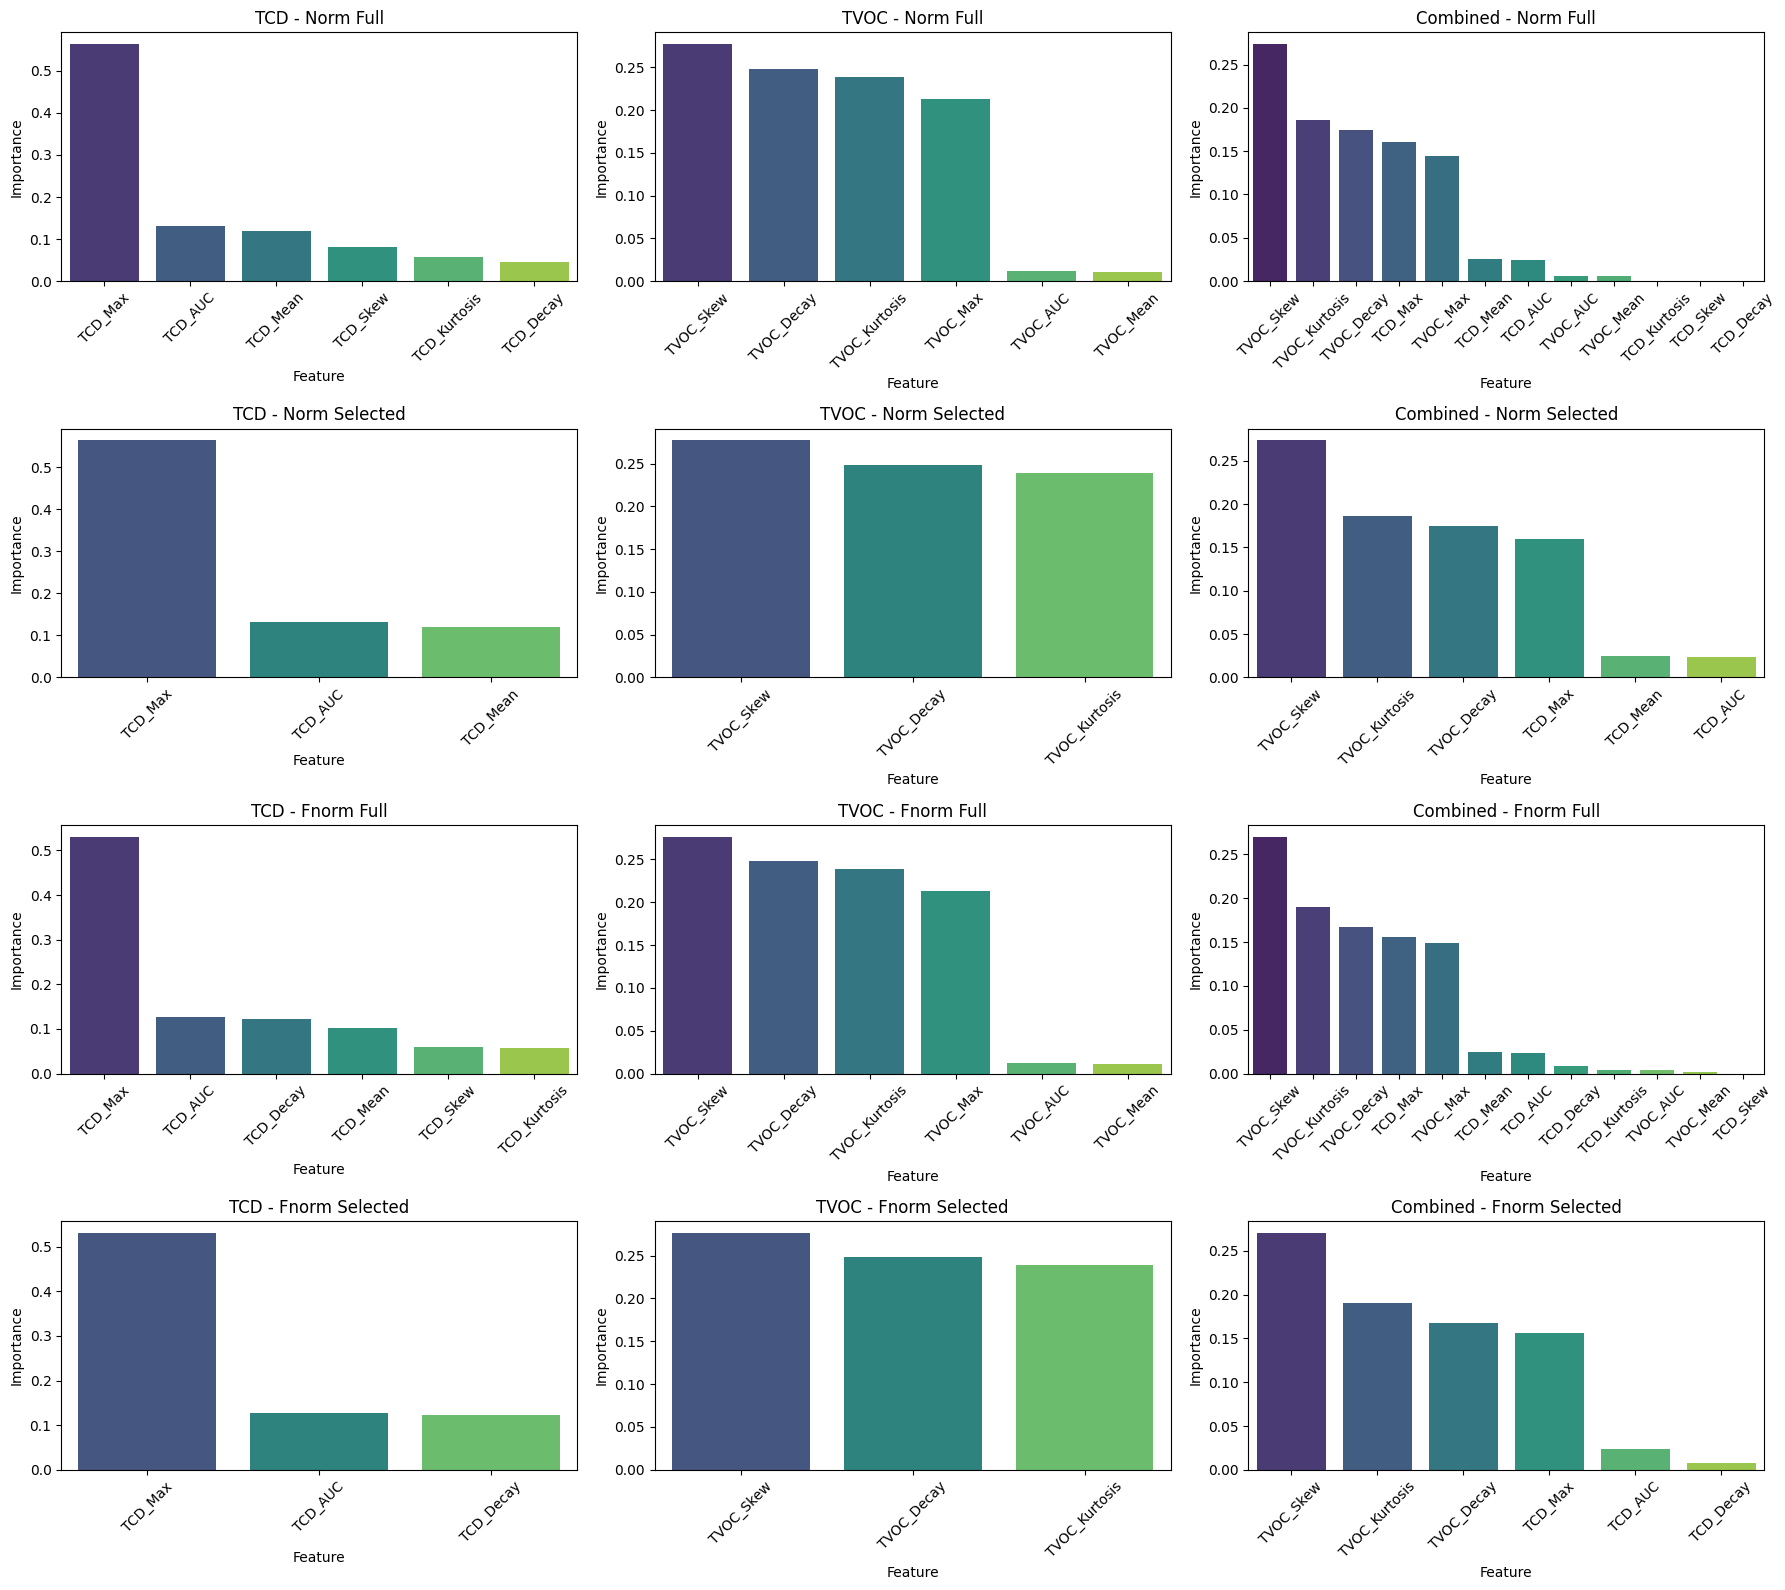

In [15]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))

importance_data = [
    (tcd_importances, tcd_cols, 'TCD - Norm Full'),
    (tvoc_importances, tvoc_cols, 'TVOC - Norm Full'),
    (combined_importances, combined_cols, 'Combined - Norm Full'),
    ([tcd_importances[tcd_cols.index(f)] for f in tcd_top3], tcd_top3, 'TCD - Norm Selected'),
    ([tvoc_importances[tvoc_cols.index(f)] for f in tvoc_top3], tvoc_top3, 'TVOC - Norm Selected'),
    ([combined_importances[combined_cols.index(f)] for f in combined_top6], combined_top6, 'Combined - Norm Selected'),

    (tcd_importances_fnorm, tcd_cols, 'TCD - Fnorm Full'),
    (tvoc_importances_fnorm, tvoc_cols, 'TVOC - Fnorm Full'),
    (combined_importances_fnorm, combined_cols, 'Combined - Fnorm Full'),
    ([tcd_importances_fnorm[tcd_cols.index(f)] for f in tcd_top3_fnorm], tcd_top3_fnorm, 'TCD - Fnorm Selected'),
    ([tvoc_importances_fnorm[tvoc_cols.index(f)] for f in tvoc_top3_fnorm], tvoc_top3_fnorm, 'TVOC - Fnorm Selected'),
    ([combined_importances_fnorm[combined_cols.index(f)] for f in combined_top6_fnorm], combined_top6_fnorm, 'Combined - Fnorm Selected'),
]

for ax, (importances, cols, title) in zip(axes.flatten(), importance_data):
    fi_df = pd.DataFrame({'Feature': cols, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    sns.barplot(x='Feature', y='Importance', data=fi_df, ax=ax, palette='viridis')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### SIMPAN SELECTED CSV

In [16]:
os.makedirs("features_selected", exist_ok=True)

df_tcd[tcd_top3 + ["Label"]].to_csv("features_selected/TCD_selected_features.csv", index=False)
df_tvoc[tvoc_top3 + ["Label"]].to_csv("features_selected/TVOC_selected_features.csv", index=False)
df_combined[combined_top6 + ["Label"]].to_csv("features_selected/Combined_selected_features.csv", index=False)

df_tcd_fnorm[tcd_top3_fnorm + ["Label"]].to_csv("features_selected/TCD_filtered_selected_features.csv", index=False)
df_tvoc_fnorm[tvoc_top3_fnorm + ["Label"]].to_csv("features_selected/TVOC_filtered_selected_features.csv", index=False)
df_combined_fnorm[combined_top6_fnorm + ["Label"]].to_csv("features_selected/Combined_filtered_selected_features.csv", index=False)

print("✅ Selected CSVs saved!")

✅ Selected CSVs saved!


### Fungsi PCA

In [17]:
def run_pca(df, feature_cols):
    X = df[feature_cols].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    return pca, X_pca, df["Label"].values

### PCA Scatter Plot

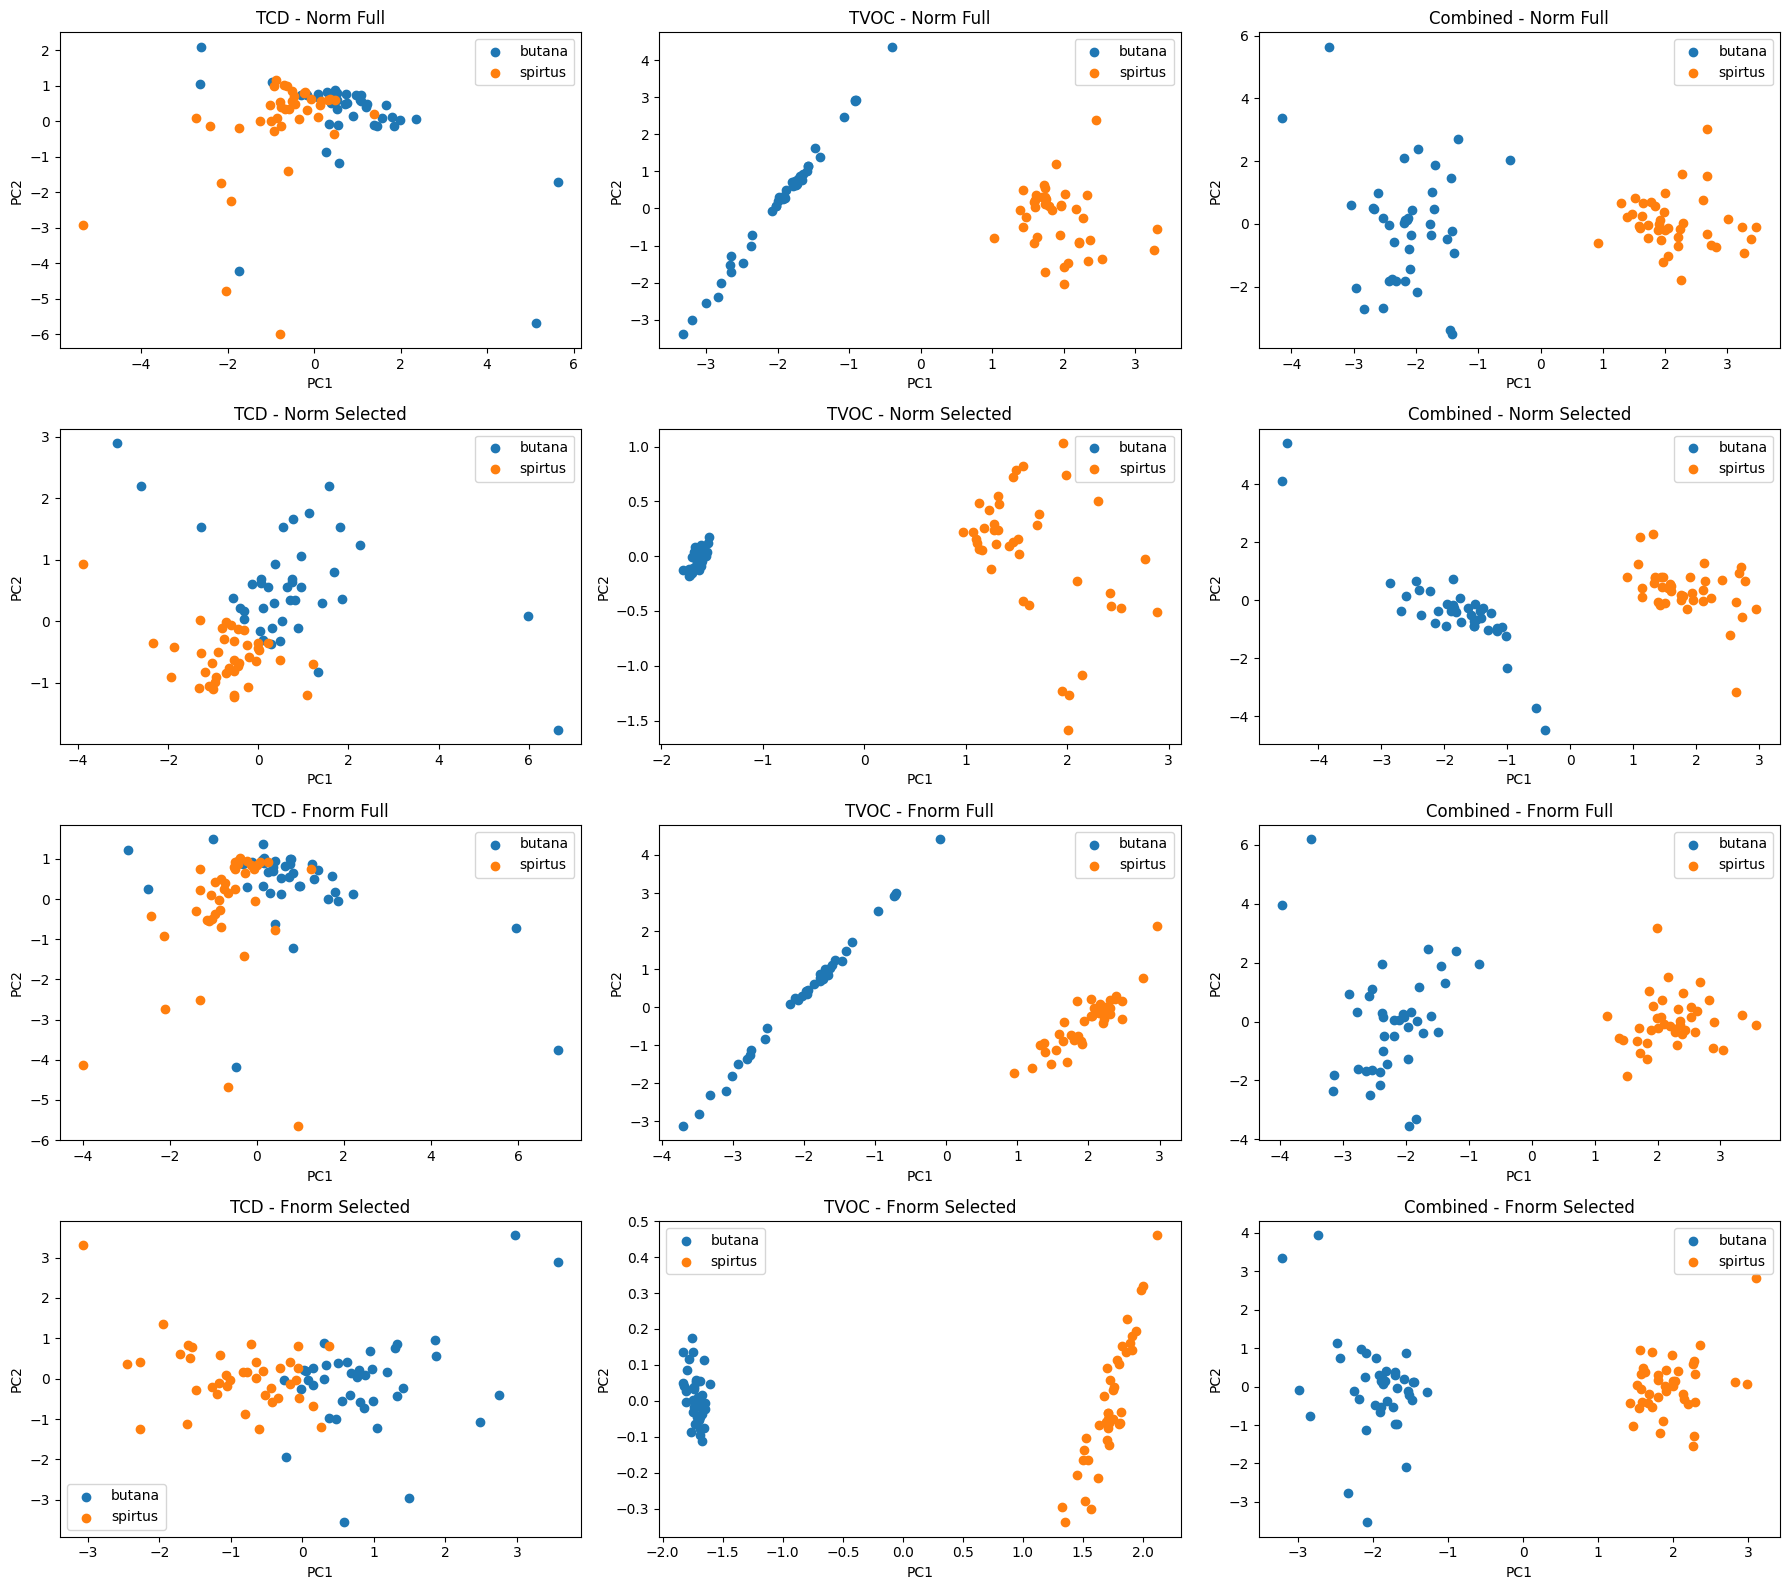

In [18]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))

pca_combinations = [
    (df_tcd, tcd_cols, 'TCD - Norm Full'),
    (df_tvoc, tvoc_cols, 'TVOC - Norm Full'),
    (df_combined, combined_cols, 'Combined - Norm Full'),
    (df_tcd, tcd_top3, 'TCD - Norm Selected'),
    (df_tvoc, tvoc_top3, 'TVOC - Norm Selected'),
    (df_combined, combined_top6, 'Combined - Norm Selected'),
    (df_tcd_fnorm, tcd_cols, 'TCD - Fnorm Full'),
    (df_tvoc_fnorm, tvoc_cols, 'TVOC - Fnorm Full'),
    (df_combined_fnorm, combined_cols, 'Combined - Fnorm Full'),
    (df_tcd_fnorm, tcd_top3_fnorm, 'TCD - Fnorm Selected'),
    (df_tvoc_fnorm, tvoc_top3_fnorm, 'TVOC - Fnorm Selected'),
    (df_combined_fnorm, combined_top6_fnorm, 'Combined - Fnorm Selected'),
]

for ax, (df, cols, title) in zip(axes.flatten(), pca_combinations):
    pca, X_pca, y = run_pca(df, cols)
    labels = df["Label"].unique()
    for label in labels:
        mask = df["Label"] == label
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=label)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend()

plt.tight_layout()
plt.show()

### Scree Plot

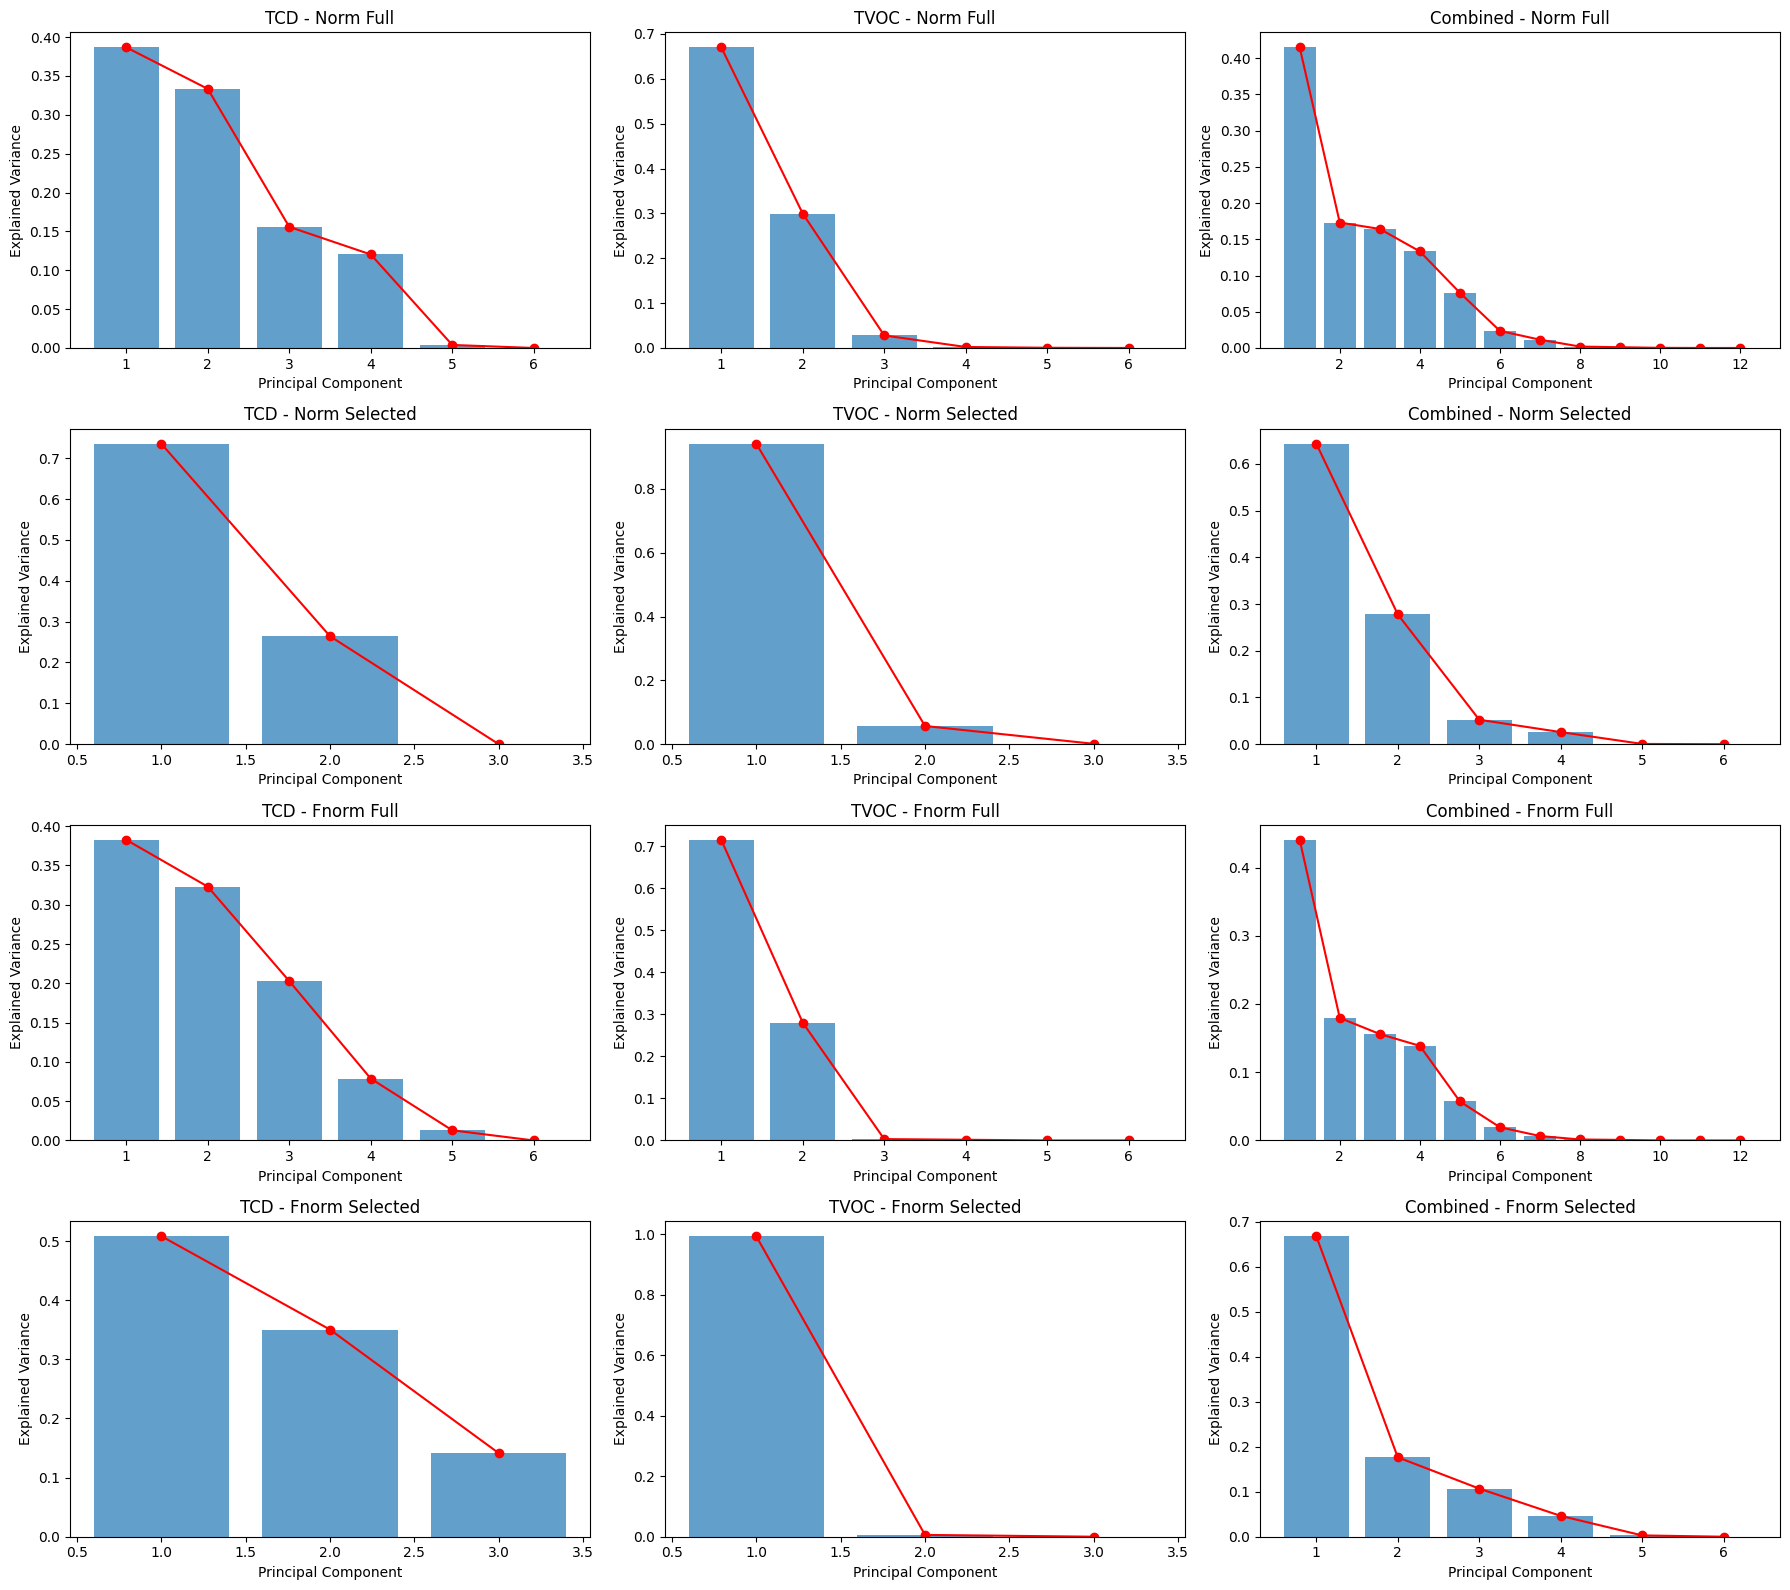

In [19]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))

for ax, (df, cols, title) in zip(axes.flatten(), pca_combinations):
    pca, _, _ = run_pca(df, cols)
    ax.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.7)
    ax.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, marker='o', color='r')
    ax.set_title(title)
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Explained Variance')

plt.tight_layout()
plt.show()

### Loading Plot

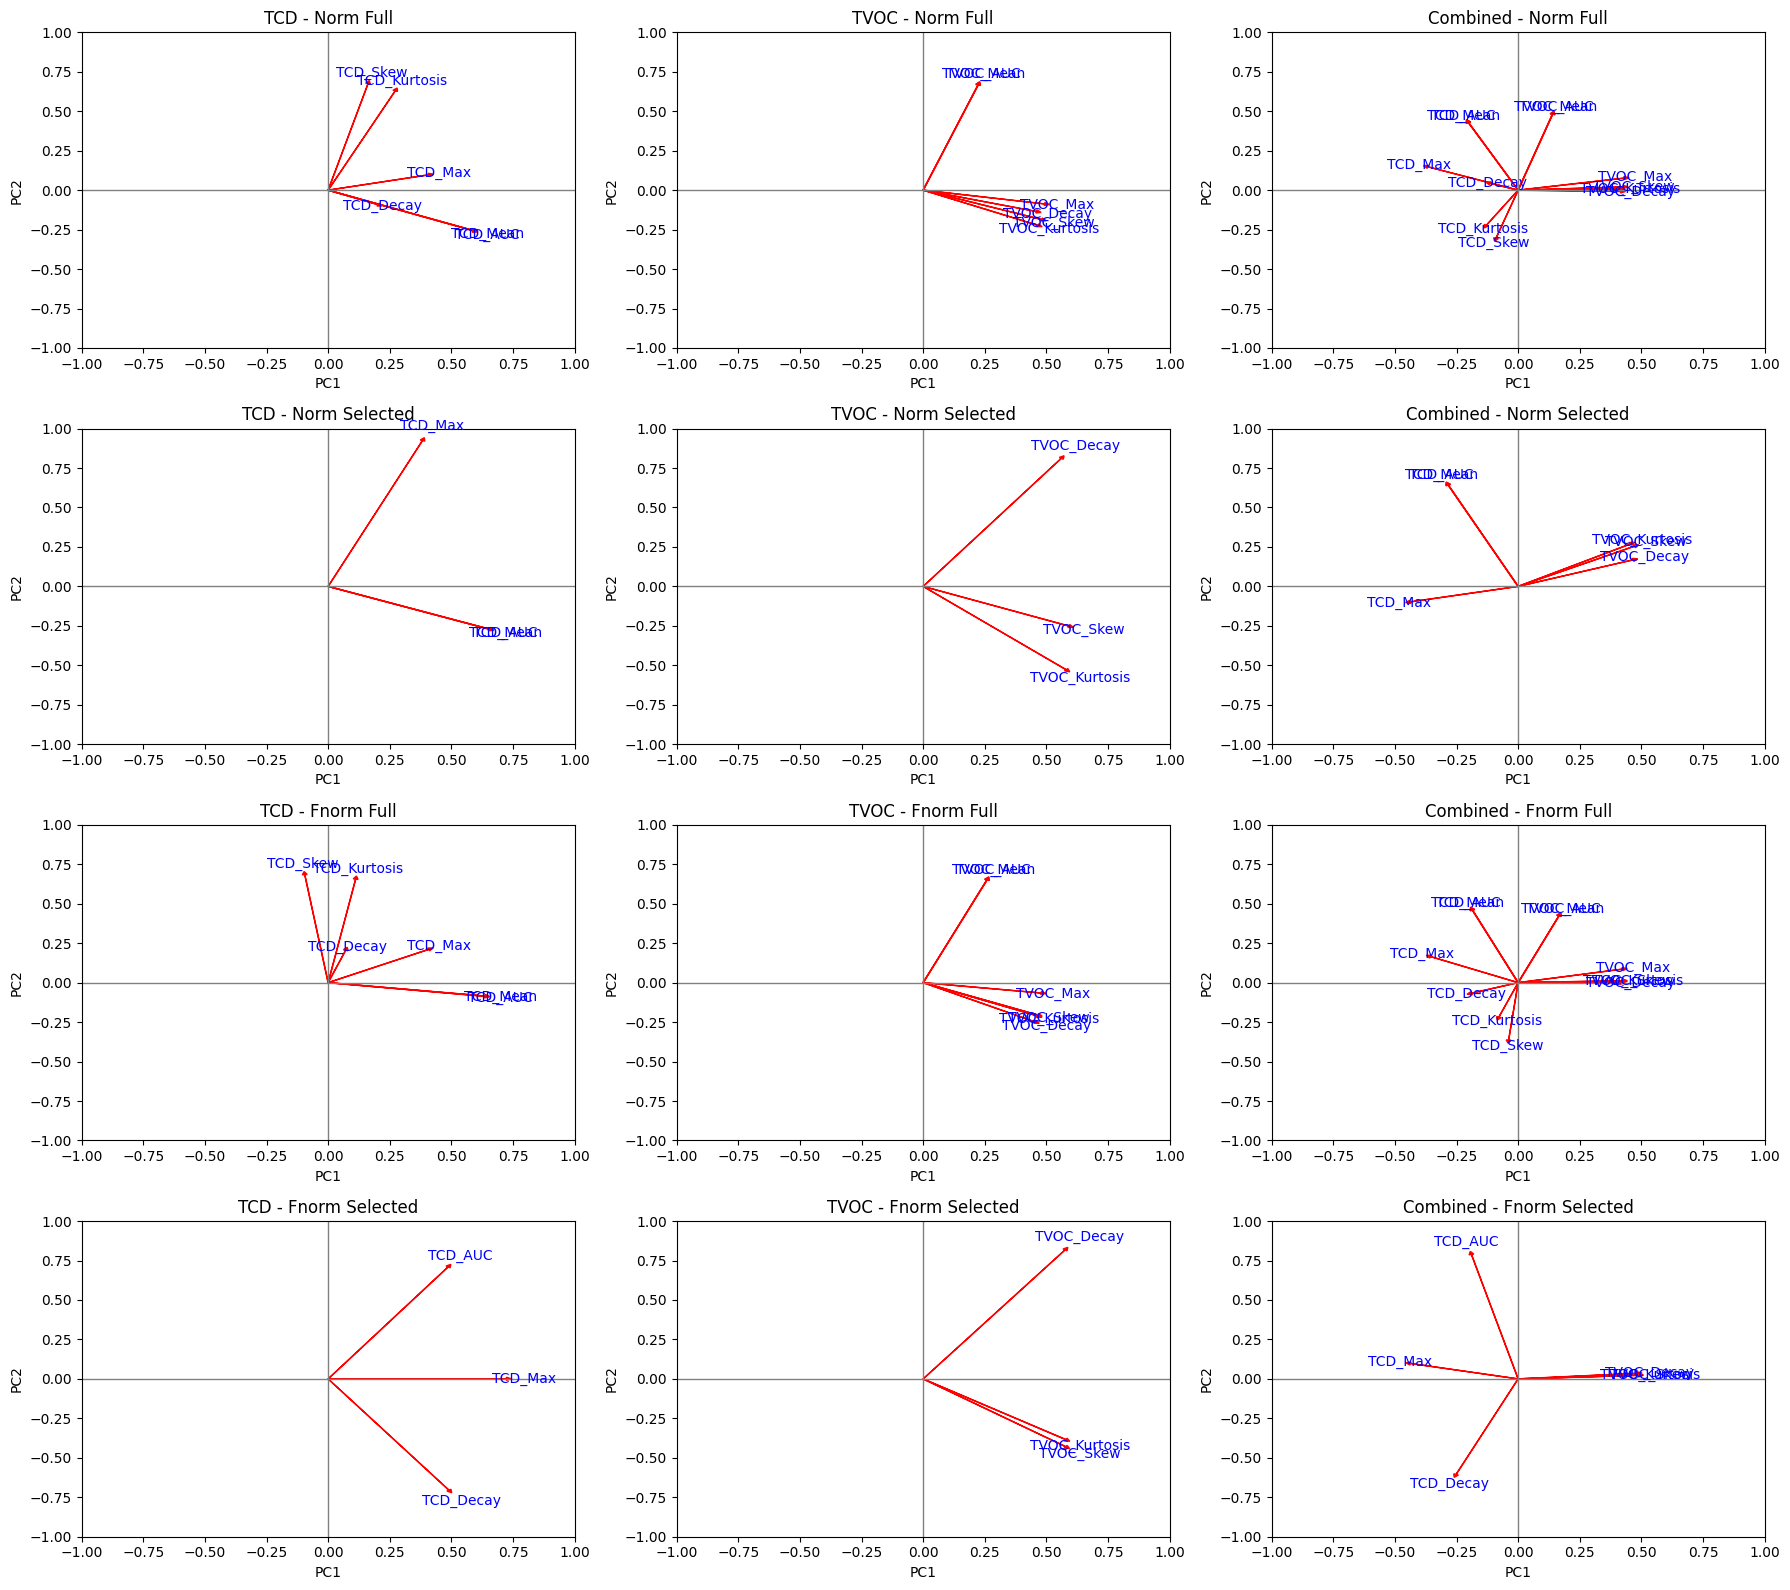

In [20]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))

for ax, (df, cols, title) in zip(axes.flatten(), pca_combinations):
    pca, _, _ = run_pca(df, cols)
    loadings = pca.components_.T[:, :2]
    for i, feature in enumerate(cols):
        ax.arrow(0, 0, loadings[i,0], loadings[i,1], head_width=0.02, head_length=0.02, color='r')
        ax.text(loadings[i,0]*1.1, loadings[i,1]*1.1, feature, color='b', ha='center', va='center')
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.axhline(0, color='grey', lw=1)
    ax.axvline(0, color='grey', lw=1)

plt.tight_layout()
plt.show()

### Diagram Batang Total Variansi

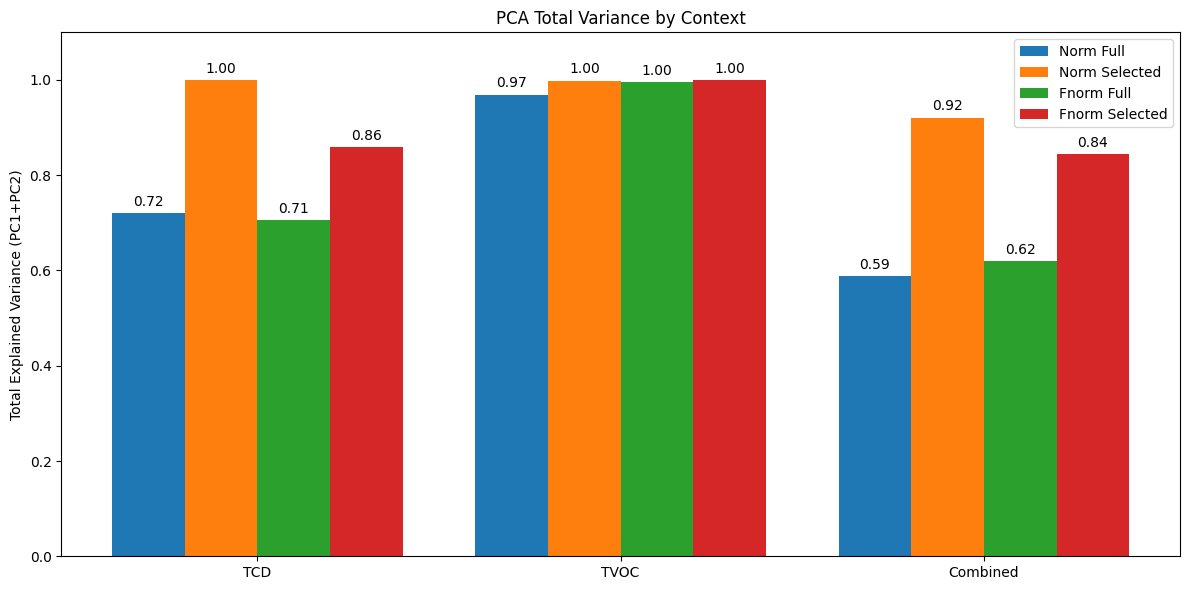

In [21]:
variance = {}

# TCD
pca_tcd_full, _, _ = run_pca(df_tcd, tcd_cols)
pca_tcd_sel, _, _ = run_pca(df_tcd, tcd_top3)
pca_tcd_fnorm_full, _, _ = run_pca(df_tcd_fnorm, tcd_cols)
pca_tcd_fnorm_sel, _, _ = run_pca(df_tcd_fnorm, tcd_top3_fnorm)

variance["TCD Norm Full"] = np.sum(pca_tcd_full.explained_variance_ratio_[:2])
variance["TCD Norm Selected"] = np.sum(pca_tcd_sel.explained_variance_ratio_[:2])
variance["TCD Fnorm Full"] = np.sum(pca_tcd_fnorm_full.explained_variance_ratio_[:2])
variance["TCD Fnorm Selected"] = np.sum(pca_tcd_fnorm_sel.explained_variance_ratio_[:2])

# TVOC
pca_tvoc_full, _, _ = run_pca(df_tvoc, tvoc_cols)
pca_tvoc_sel, _, _ = run_pca(df_tvoc, tvoc_top3)
pca_tvoc_fnorm_full, _, _ = run_pca(df_tvoc_fnorm, tvoc_cols)
pca_tvoc_fnorm_sel, _, _ = run_pca(df_tvoc_fnorm, tvoc_top3_fnorm)

variance["TVOC Norm Full"] = np.sum(pca_tvoc_full.explained_variance_ratio_[:2])
variance["TVOC Norm Selected"] = np.sum(pca_tvoc_sel.explained_variance_ratio_[:2])
variance["TVOC Fnorm Full"] = np.sum(pca_tvoc_fnorm_full.explained_variance_ratio_[:2])
variance["TVOC Fnorm Selected"] = np.sum(pca_tvoc_fnorm_sel.explained_variance_ratio_[:2])

# Combined
pca_combined_full, _, _ = run_pca(df_combined, combined_cols)
pca_combined_sel, _, _ = run_pca(df_combined, combined_top6)
pca_combined_fnorm_full, _, _ = run_pca(df_combined_fnorm, combined_cols)
pca_combined_fnorm_sel, _, _ = run_pca(df_combined_fnorm, combined_top6_fnorm)

variance["Combined Norm Full"] = np.sum(pca_combined_full.explained_variance_ratio_[:2])
variance["Combined Norm Selected"] = np.sum(pca_combined_sel.explained_variance_ratio_[:2])
variance["Combined Fnorm Full"] = np.sum(pca_combined_fnorm_full.explained_variance_ratio_[:2])
variance["Combined Fnorm Selected"] = np.sum(pca_combined_fnorm_sel.explained_variance_ratio_[:2])

labels = ["TCD", "TVOC", "Combined"]
x = np.arange(len(labels))
width = 0.2  # Lebar setiap bar

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - 1.5*width, 
                [variance[f"{k} Norm Full"] for k in labels], 
                width, label='Norm Full')

rects2 = ax.bar(x - 0.5*width, 
                [variance[f"{k} Norm Selected"] for k in labels], 
                width, label='Norm Selected')

rects3 = ax.bar(x + 0.5*width, 
                [variance[f"{k} Fnorm Full"] for k in labels], 
                width, label='Fnorm Full')

rects4 = ax.bar(x + 1.5*width, 
                [variance[f"{k} Fnorm Selected"] for k in labels], 
                width, label='Fnorm Selected')

ax.set_ylabel('Total Explained Variance (PC1+PC2)')
ax.set_title('PCA Total Variance by Context')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.legend()

# Label angka
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(rects1)
add_labels(rects2)
add_labels(rects3)
add_labels(rects4)

plt.tight_layout()
plt.show()

### Silhouette score

In [22]:
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score
# import matplotlib.pyplot as plt

# def run_pca(df, feature_cols):
#     X = df[feature_cols].values
#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(X)
#     pca = PCA(n_components=2) # Menggunakan 2 komponen untuk K-Means agar tidak terlalu banyak dimensi
#     X_pca = pca.fit_transform(X_scaled)
#     return pca, X_pca, df["Label"].values # Mengembalikan label asli untuk menentukan n_clusters


# # List untuk menyimpan silhouette scores dan judul
# silhouette_scores = []
# titles = []

# # Iterasi melalui setiap kombinasi PCA
# pca_combinations = [
#     (df_tcd, tcd_cols, 'TCD - Norm Full'),
#     (df_tvoc, tvoc_cols, 'TVOC - Norm Full'),
#     (df_combined, combined_cols, 'Combined - Norm Full'),
#     (df_tcd, tcd_top3, 'TCD - Norm Selected'),
#     (df_tvoc, tvoc_top3, 'TVOC - Norm Selected'),
#     (df_combined, combined_top6, 'Combined - Norm Selected'),
#     (df_tcd_fnorm, tcd_cols, 'TCD - Fnorm Full'),
#     (df_tvoc_fnorm, tvoc_cols, 'TVOC - Fnorm Full'),
#     (df_combined_fnorm, combined_cols, 'Combined - Fnorm Full'),
#     (df_tcd_fnorm, tcd_top3_fnorm, 'TCD - Fnorm Selected'),
#     (df_tvoc_fnorm, tvoc_top3_fnorm, 'TVOC - Fnorm Selected'),
#     (df_combined_fnorm, combined_top6_fnorm, 'Combined - Fnorm Selected'),
# ]

# for i, (df, cols, title) in enumerate(pca_combinations):
#     print(f"Processing: {title} ({i+1}/{len(pca_combinations)})")
#     pca, X_pca, y_true = run_pca(df, cols)

#     # Menentukan jumlah kluster berdasarkan jumlah label unik
#     # Pastikan y_true memiliki label yang cukup untuk clustering
#     n_clusters = len(np.unique(y_true))
#     if n_clusters < 2:
#         print(f"  Skipping {title}: Not enough unique labels for clustering (need >= 2).")
#         silhouette_scores.append(np.nan) # Tambahkan NaN jika tidak bisa dihitung
#         titles.append(title)
#         continue

#     # Lakukan K-Means clustering pada data yang sudah di PCA
#     # n_init='auto' atau nilai integer seperti 10 disarankan untuk versi scikit-learn terbaru
#     kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
#     cluster_labels = kmeans.fit_predict(X_pca)

#     # Hitung silhouette score
#     score = silhouette_score(X_pca, cluster_labels)
#     silhouette_scores.append(score)
#     titles.append(title)
#     print(f"  Silhouette Score: {score:.4f}")

# # Buat bar plot dari silhouette scores
# plt.figure(figsize=(15, 8)) # Ukuran figure yang lebih besar untuk bar plot
# bars = plt.bar(titles, silhouette_scores, color='skyblue')
# plt.xlabel('Kombinasi PCA dan Data')
# plt.ylabel('Silhouette Score')
# plt.title('Silhouette Scores untuk Berbagai Kombinasi PCA dan Data Clustering')
# plt.xticks(rotation=45, ha='right') # Putar label X agar tidak tumpang tindih
# plt.grid(axis='y', linestyle='--', alpha=0.7)

# # Tambahkan nilai di atas setiap bar
# for bar in bars:
#     yval = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom')

# plt.tight_layout() # Sesuaikan layout agar semua elemen terlihat
# plt.show()

Processing TCD Combinations...
  TCD Norm Full Silhouette: 0.3395
  TCD Norm Selected Silhouette: 0.3880
  TCD Fnorm Full Silhouette: 0.4315
  TCD Fnorm Selected Silhouette: 0.3388

Processing TVOC Combinations...
  TVOC Norm Full Silhouette: 0.6419
  TVOC Norm Selected Silhouette: 0.8452
  TVOC Fnorm Full Silhouette: 0.6735
  TVOC Fnorm Selected Silhouette: 0.9420

Processing Combined Combinations...
  Combined Norm Full Silhouette: 0.6248
  Combined Norm Selected Silhouette: 0.6630
  Combined Fnorm Full Silhouette: 0.6445
  Combined Fnorm Selected Silhouette: 0.7168


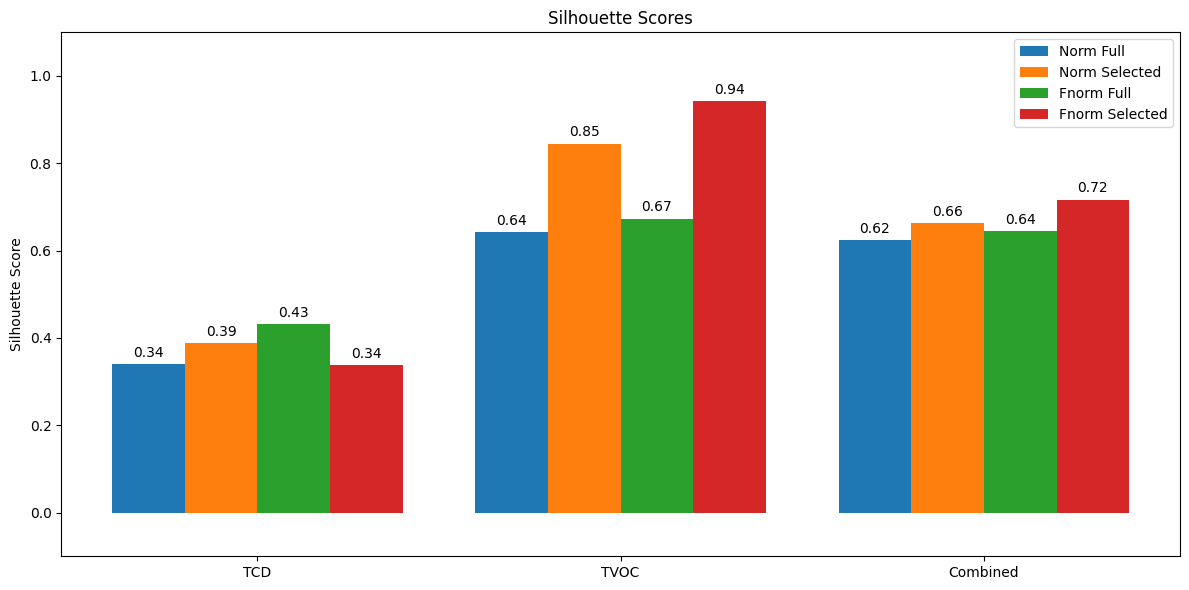

In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

def run_pca(df, feature_cols):
    X = df[feature_cols].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    # PCA dengan 2 komponen karena silhouette score biasanya relevan di ruang dimensi rendah
    # dan jika kita ingin mencoba meniru visualisasi 2D kluster
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    return pca, X_pca, df["Label"].values # Mengembalikan objek pca, X_pca, dan label asli

# Dictionary untuk menyimpan Silhouette Scores
silhouette_scores_dict = {}

# --- PROSES UNTUK TCD ---
# Pastikan jumlah kluster (n_clusters) sesuai dengan karakteristik data Anda
# Di sini, saya akan gunakan jumlah label unik sebagai n_clusters
n_clusters_tcd = len(np.unique(df_tcd["Label"].values))
n_clusters_tvoc = len(np.unique(df_tvoc["Label"].values))
n_clusters_combined = len(np.unique(df_combined["Label"].values))

if n_clusters_tcd < 2 or n_clusters_tvoc < 2 or n_clusters_combined < 2:
    print("Warning: Some datasets have less than 2 unique labels. Silhouette score requires at least 2 clusters.")


# TCD
print("Processing TCD Combinations...")
pca_tcd_full, X_pca_tcd_full, y_tcd_full = run_pca(df_tcd, tcd_cols)
kmeans_tcd_full = KMeans(n_clusters=n_clusters_tcd, random_state=42, n_init='auto')
clusters_tcd_full = kmeans_tcd_full.fit_predict(X_pca_tcd_full)
silhouette_scores_dict["TCD Norm Full"] = silhouette_score(X_pca_tcd_full, clusters_tcd_full)
print(f"  TCD Norm Full Silhouette: {silhouette_scores_dict['TCD Norm Full']:.4f}")

pca_tcd_sel, X_pca_tcd_sel, y_tcd_sel = run_pca(df_tcd, tcd_top3)
kmeans_tcd_sel = KMeans(n_clusters=n_clusters_tcd, random_state=42, n_init='auto')
clusters_tcd_sel = kmeans_tcd_sel.fit_predict(X_pca_tcd_sel)
silhouette_scores_dict["TCD Norm Selected"] = silhouette_score(X_pca_tcd_sel, clusters_tcd_sel)
print(f"  TCD Norm Selected Silhouette: {silhouette_scores_dict['TCD Norm Selected']:.4f}")

pca_tcd_fnorm_full, X_pca_tcd_fnorm_full, y_tcd_fnorm_full = run_pca(df_tcd_fnorm, tcd_cols)
kmeans_tcd_fnorm_full = KMeans(n_clusters=n_clusters_tcd, random_state=42, n_init='auto')
clusters_tcd_fnorm_full = kmeans_tcd_fnorm_full.fit_predict(X_pca_tcd_fnorm_full)
silhouette_scores_dict["TCD Fnorm Full"] = silhouette_score(X_pca_tcd_fnorm_full, clusters_tcd_fnorm_full)
print(f"  TCD Fnorm Full Silhouette: {silhouette_scores_dict['TCD Fnorm Full']:.4f}")

pca_tcd_fnorm_sel, X_pca_tcd_fnorm_sel, y_tcd_fnorm_sel = run_pca(df_tcd_fnorm, tcd_top3_fnorm)
kmeans_tcd_fnorm_sel = KMeans(n_clusters=n_clusters_tcd, random_state=42, n_init='auto')
clusters_tcd_fnorm_sel = kmeans_tcd_fnorm_sel.fit_predict(X_pca_tcd_fnorm_sel)
silhouette_scores_dict["TCD Fnorm Selected"] = silhouette_score(X_pca_tcd_fnorm_sel, clusters_tcd_fnorm_sel)
print(f"  TCD Fnorm Selected Silhouette: {silhouette_scores_dict['TCD Fnorm Selected']:.4f}")


# --- PROSES UNTUK TVOC ---
print("\nProcessing TVOC Combinations...")
pca_tvoc_full, X_pca_tvoc_full, y_tvoc_full = run_pca(df_tvoc, tvoc_cols)
kmeans_tvoc_full = KMeans(n_clusters=n_clusters_tvoc, random_state=42, n_init='auto')
clusters_tvoc_full = kmeans_tvoc_full.fit_predict(X_pca_tvoc_full)
silhouette_scores_dict["TVOC Norm Full"] = silhouette_score(X_pca_tvoc_full, clusters_tvoc_full)
print(f"  TVOC Norm Full Silhouette: {silhouette_scores_dict['TVOC Norm Full']:.4f}")

pca_tvoc_sel, X_pca_tvoc_sel, y_tvoc_sel = run_pca(df_tvoc, tvoc_top3)
kmeans_tvoc_sel = KMeans(n_clusters=n_clusters_tvoc, random_state=42, n_init='auto')
clusters_tvoc_sel = kmeans_tvoc_sel.fit_predict(X_pca_tvoc_sel)
silhouette_scores_dict["TVOC Norm Selected"] = silhouette_score(X_pca_tvoc_sel, clusters_tvoc_sel)
print(f"  TVOC Norm Selected Silhouette: {silhouette_scores_dict['TVOC Norm Selected']:.4f}")

pca_tvoc_fnorm_full, X_pca_tvoc_fnorm_full, y_tvoc_fnorm_full = run_pca(df_tvoc_fnorm, tvoc_cols)
kmeans_tvoc_fnorm_full = KMeans(n_clusters=n_clusters_tvoc, random_state=42, n_init='auto')
clusters_tvoc_fnorm_full = kmeans_tvoc_fnorm_full.fit_predict(X_pca_tvoc_fnorm_full)
silhouette_scores_dict["TVOC Fnorm Full"] = silhouette_score(X_pca_tvoc_fnorm_full, clusters_tvoc_fnorm_full)
print(f"  TVOC Fnorm Full Silhouette: {silhouette_scores_dict['TVOC Fnorm Full']:.4f}")

pca_tvoc_fnorm_sel, X_pca_tvoc_fnorm_sel, y_tvoc_fnorm_sel = run_pca(df_tvoc_fnorm, tvoc_top3_fnorm)
kmeans_tvoc_fnorm_sel = KMeans(n_clusters=n_clusters_tvoc, random_state=42, n_init='auto')
clusters_tvoc_fnorm_sel = kmeans_tvoc_fnorm_sel.fit_predict(X_pca_tvoc_fnorm_sel)
silhouette_scores_dict["TVOC Fnorm Selected"] = silhouette_score(X_pca_tvoc_fnorm_sel, clusters_tvoc_fnorm_sel)
print(f"  TVOC Fnorm Selected Silhouette: {silhouette_scores_dict['TVOC Fnorm Selected']:.4f}")


# --- PROSES UNTUK Combined ---
print("\nProcessing Combined Combinations...")
pca_combined_full, X_pca_combined_full, y_combined_full = run_pca(df_combined, combined_cols)
kmeans_combined_full = KMeans(n_clusters=n_clusters_combined, random_state=42, n_init='auto')
clusters_combined_full = kmeans_combined_full.fit_predict(X_pca_combined_full)
silhouette_scores_dict["Combined Norm Full"] = silhouette_score(X_pca_combined_full, clusters_combined_full)
print(f"  Combined Norm Full Silhouette: {silhouette_scores_dict['Combined Norm Full']:.4f}")

pca_combined_sel, X_pca_combined_sel, y_combined_sel = run_pca(df_combined, combined_top6)
kmeans_combined_sel = KMeans(n_clusters=n_clusters_combined, random_state=42, n_init='auto')
clusters_combined_sel = kmeans_combined_sel.fit_predict(X_pca_combined_sel)
silhouette_scores_dict["Combined Norm Selected"] = silhouette_score(X_pca_combined_sel, clusters_combined_sel)
print(f"  Combined Norm Selected Silhouette: {silhouette_scores_dict['Combined Norm Selected']:.4f}")

pca_combined_fnorm_full, X_pca_combined_fnorm_full, y_combined_fnorm_full = run_pca(df_combined_fnorm, combined_cols)
kmeans_combined_fnorm_full = KMeans(n_clusters=n_clusters_combined, random_state=42, n_init='auto')
clusters_combined_fnorm_full = kmeans_combined_fnorm_full.fit_predict(X_pca_combined_fnorm_full)
silhouette_scores_dict["Combined Fnorm Full"] = silhouette_score(X_pca_combined_fnorm_full, clusters_combined_fnorm_full)
print(f"  Combined Fnorm Full Silhouette: {silhouette_scores_dict['Combined Fnorm Full']:.4f}")

pca_combined_fnorm_sel, X_pca_combined_fnorm_sel, y_combined_fnorm_sel = run_pca(df_combined_fnorm, combined_top6_fnorm)
kmeans_combined_fnorm_sel = KMeans(n_clusters=n_clusters_combined, random_state=42, n_init='auto')
clusters_combined_fnorm_sel = kmeans_combined_fnorm_sel.fit_predict(X_pca_combined_fnorm_sel)
silhouette_scores_dict["Combined Fnorm Selected"] = silhouette_score(X_pca_combined_fnorm_sel, clusters_combined_fnorm_sel)
print(f"  Combined Fnorm Selected Silhouette: {silhouette_scores_dict['Combined Fnorm Selected']:.4f}")


# --- BAGIAN PLOTTING BAR PLOT ---
labels = ["TCD", "TVOC", "Combined"]
x = np.arange(len(labels))
width = 0.2  # Lebar setiap bar

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - 1.5*width,
                [silhouette_scores_dict[f"{k} Norm Full"] for k in labels],
                width, label='Norm Full')

rects2 = ax.bar(x - 0.5*width,
                [silhouette_scores_dict[f"{k} Norm Selected"] for k in labels],
                width, label='Norm Selected')

rects3 = ax.bar(x + 0.5*width,
                [silhouette_scores_dict[f"{k} Fnorm Full"] for k in labels],
                width, label='Fnorm Full')

rects4 = ax.bar(x + 1.5*width,
                [silhouette_scores_dict[f"{k} Fnorm Selected"] for k in labels],
                width, label='Fnorm Selected')

ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Scores')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(-0.1, 1.1) # Silhouette score range from -1 to 1, set limits for better visualization
ax.legend()

# Label angka
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(rects1)
add_labels(rects2)
add_labels(rects3)
add_labels(rects4)

plt.tight_layout()
plt.show()